In [172]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
import requests
load_dotenv()
import os
API_KEY = os.getenv("ALPHA_VANTAGE_API_KEY")


In [173]:
os.environ["LANGCHAIN_PROJECT"] = "initial_agentic_workflow"

In [174]:
from langgraph.graph.message import add_messages

# this import is used for adding a reducer function. Although operator.add also works but this inbuilt function is more optimised to handle state chnages .

In [175]:
class chatstate(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]


In [176]:
chat_model = ChatOpenAI(model='gpt-4o-mini')

In [177]:
search_tool = TavilySearch(max_results=3)

@tool()
def calculator(num1: float, num2: float, operator : str) -> dict:
    """
    Performs basic arithmetic operations on two numbers.
    Supported Operations are sum, div, mul, sub
    """
    try:
        if operator == 'sum':
            result= num1 + num2
        elif operator == 'sub':
            result = num1 - num2
        elif operator == 'mul':
            result = num1 * num2
        elif operator == 'div':
            if num2 == 0:
                return { "error": "Error: Cannot divide by zero!"}
            result = num1 / num2
            return {"result": result}

        else:
            return {"error": "Error: Invalid operator!"}

    except Exception as e:
        return {"error": str(e)}

@tool()
def get_stock_price(symbol : str, date: str) -> dict:
    """
    this is a function which calls yfinance to get stock prices for a given symbol/ticker and on a given date

    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={API_KEY}"
    response = requests.get(url)
    return response.json()


In [178]:
tools = get_stock_price,calculator, search_tool
chat_model_with_tools = chat_model.bind_tools(tools)

In [179]:
tool_node = ToolNode(tools)

In [180]:
def chat_bot(state: chatstate):

    messages = state['messages']

    response = chat_model_with_tools.invoke(messages)

    return {'messages': [response]}



In [181]:
graph = StateGraph(chatstate)

In [182]:

graph.add_node("chat",chat_bot)
graph.add_node("tools",tool_node)


In [183]:
graph.add_edge(START, "chat")
graph.add_conditional_edges("chat",tools_condition)
graph.add_edge("tools","chat")


In [184]:
chatbot = graph.compile()

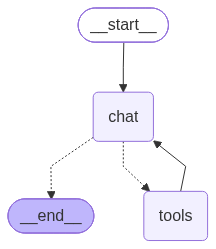

In [185]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [186]:
out = chatbot.invoke({"messages":[HumanMessage(content="What is multiplication of 4 and 5")]})
print(out["messages"][-1].content)

The multiplication of 4 and 5 is 20.


In [187]:
out = chatbot.invoke({"messages":[HumanMessage(content="What is stock price of microsoft today")]})
print(out["messages"][-1].content)

The stock price of Microsoft (MSFT) today is $499.99. It opened at $499.21, reached a high of $505.18, and had a low of $498.73.


In [189]:
out = chatbot.invoke({"messages":[HumanMessage(content=" what is the top news of today")]})
print(out["messages"][-1].content)

Here are some of the top news stories from today:

1. **FDA Approvals in Healthcare**: On August 5, 2026, the FDA approved oveporexton (Orzeyful) tablets for narcolepsy type 1 in adults, marking it as the first medicine to directly target orexin signaling loss. This week also saw new results from the phase 3 VISIONARY trial and the FDA's Fast Track Designation for Aravax's investigational peptide immunotherapy for peanut allergy. [Read more here](https://www.hcplive.com/view/the-hcpfive-top-news-for-healthcare-providers-from-the-week-of-08-02).

2. **Ukrainian Drone Strike**: A Ukrainian drone struck Russian military installations, resulting in one of Kyiv's deadliest attacks, which killed 13 in central Russia. Meanwhile, heavy seasonal monsoon rains in the Philippines have left at least 13 people dead. [Watch the news bulletin](https://www.euronews.com/video/2026/08/10/latest-news-bulletin-august-10th-2026-evening).

3. **Local Arrests and Political Polls**: In U.S. news, deputies arr